# Did the Ads Actually Work? A Marketing A/B Test

**Question.** A company ran a marketing campaign where most users saw the real ad and a small control group saw a public service announcement (PSA) in the same slot. Did the ad actually cause more conversions than the control, is the difference statistically significant, and how much can we trust the "more ads, more conversion" pattern inside the ad group?

**Data.** A real marketing experiment of 588,101 users (one row per user). Columns: `user_id`, `test_group` (ad or psa), `converted` (True/False), `total_ads`, `most_ads_day`, `most_ads_hour`.

**Approach.** Validate the data, measure the conversion lift, test it with a two-proportion z-test and a chi-square test, quantify the uncertainty with a confidence interval and a bootstrap, then pull apart the exposure confound and the timing segments.

This is a portfolio project. The findings demonstrate method, they are not a real campaign decision.

## 1. Load and tidy

In [ ]:
import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/marketing_AB.csv")
df = df.rename(columns={
    df.columns[0]: "row_index",
    "user id": "user_id", "test group": "test_group",
    "total ads": "total_ads", "most ads day": "most_ads_day",
    "most ads hour": "most_ads_hour"})
print("rows, columns:", df.shape)
df.head()

rows, columns: (588101, 7)


   row_index  user_id test_group  converted  total_ads most_ads_day  most_ads_hour
0          0  1069124         ad      False        130       Monday             20
1          1  1119715         ad      False         93      Tuesday             22
2          2  1144181         ad      False         21      Tuesday             18
3          3  1435133         ad      False        355      Tuesday             10
4          4  1015700         ad      False        276       Friday             14

## 2. Data quality

Before any test, confirm the experiment data is clean: no missing values, no duplicate users (which would break the independence assumption), and a clean boolean outcome.

In [ ]:
print("nulls per column:")
print(df.isnull().sum().to_string())
print("\nduplicate user_id rows:", int(df.user_id.duplicated().sum()))
print("converted values:", df.converted.unique().tolist())
print("total rows:", len(df))

nulls per column:
row_index        0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0

duplicate user_id rows: 0
converted values: [False, True]
total rows: 588101


The data is clean: zero nulls, zero duplicate users, and `converted` is a clean boolean. No cleaning needed, so we can trust the comparison.

## 3. Group balance

This experiment is deliberately imbalanced. Almost everyone saw the ad, and only a small slice saw the control PSA. That is worth stating up front, because the small control group is what limits our statistical power later.

In [ ]:
counts = df.test_group.value_counts()
shares = (counts / len(df) * 100).round(2)
balance = pd.DataFrame({"users": counts, "share_%": shares})
print(balance.to_string())

             users  share_%
test_group                 
ad          564577     96.0
psa          23524      4.0


So 96% of users are in the ad group and 4% in the control. The randomized comparison we care about is **ad vs. psa**, and the control group of about 23,500 users is the binding constraint on precision.

## 4. Headline result: conversion by group

The core metric is the conversion rate in each group, the absolute lift (percentage points), and the relative lift (percent).

              sum   count  rate_%
test_group                       
ad          14423  564577   2.555
psa           420   23524   1.785

absolute lift: 0.769 percentage points
relative lift: 43.1%


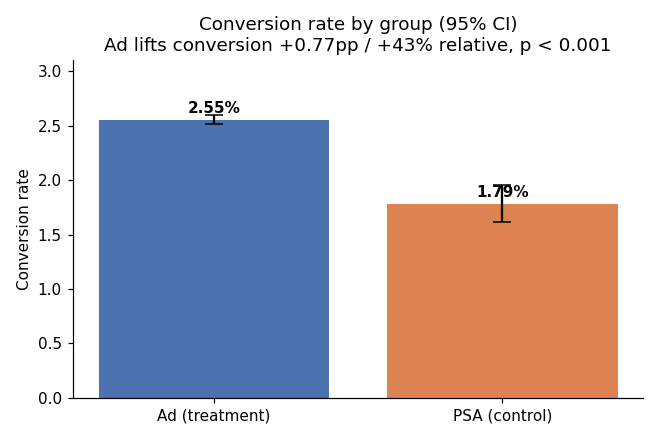

In [ ]:
conv = df.groupby("test_group")["converted"].agg(sum="sum", count="count", rate="mean")
conv["rate_%"] = (conv["rate"] * 100).round(3)
print(conv[["sum","count","rate_%"]].to_string())

p_ad, n_ad = conv.loc["ad","rate"], conv.loc["ad","count"]
p_ps, n_ps = conv.loc["psa","rate"], conv.loc["psa","count"]
abs_lift = (p_ad - p_ps) * 100
rel_lift = (p_ad / p_ps - 1) * 100
print(f"\nabsolute lift: {abs_lift:.3f} percentage points")
print(f"relative lift: {rel_lift:.1f}%")

The ad group converts at **2.55%** versus **1.79%** for the control. That is a **0.77 percentage point** absolute lift and a **+43%** relative lift. The next question is whether a gap that size is real or could be explained by chance, given the small control group.

## 5. Significance testing

Two standard tests for a difference in conversion rates between two groups:

- A **two-proportion z-test** (pooled), which asks how many standard errors apart the two rates are.
- A **chi-square test of independence** on the 2x2 table of group by converted.

No SciPy in this environment, so both are computed directly from their formulas. The p-value uses the error function for the normal tail.

In [ ]:
# Two-proportion z-test (pooled standard error)
x_ad, x_ps = conv.loc["ad","sum"], conv.loc["psa","sum"]
p_pool = (x_ad + x_ps) / (n_ad + n_ps)
se_pool = math.sqrt(p_pool * (1 - p_pool) * (1/n_ad + 1/n_ps))
z = (p_ad - p_ps) / se_pool
p_value = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))
print(f"z-statistic = {z:.3f}")
print(f"two-sided p-value = {p_value:.3e}")

# Chi-square test of independence (2x2)
ct = pd.crosstab(df.test_group, df.converted)
obs = ct.values.astype(float)
exp = obs.sum(1, keepdims=True) @ obs.sum(0, keepdims=True) / obs.sum()
chi2 = ((obs - exp)**2 / exp).sum()
print(f"\nchi-square = {chi2:.2f} (df = 1)")
print("contingency table:")
print(ct.to_string())

z-statistic = 7.370
two-sided p-value = 1.705e-13

chi-square = 54.32 (df = 1)
contingency table:
converted    False  True 
test_group               
ad          550154  14423
psa          23104    420


Both tests agree and are decisive. The z-statistic of **7.37** gives a p-value around **1.7e-13**, and chi-square is **54.3** on 1 degree of freedom (well past the 3.84 cutoff for p = 0.05). We can reject the idea that the ad and control convert at the same rate. The lift is real.

## 6. How big, and how sure: confidence interval and bootstrap

A p-value tells us the effect is real, not how large it is. For that we need the lift with a confidence interval. Then we confirm it a second way with a bootstrap, resampling each group with replacement 10,000 times and looking at the spread of the difference.

absolute lift: 0.769 pp
95% CI (analytic): [0.595, 0.943] pp
95% CI (bootstrap): [0.597, 0.942] pp
share of bootstrap samples at or below zero: 0.0000


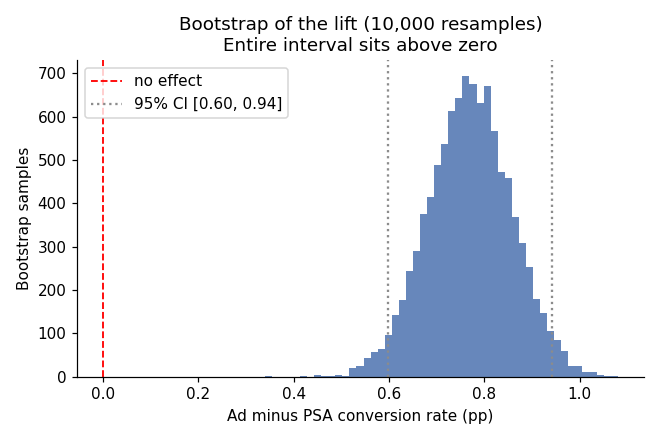

In [ ]:
# 95% confidence interval on the absolute lift (unpooled SE)
se_unp = math.sqrt(p_ad*(1-p_ad)/n_ad + p_ps*(1-p_ps)/n_ps)
diff = (p_ad - p_ps) * 100
ci_lo, ci_hi = diff - 1.96*se_unp*100, diff + 1.96*se_unp*100
print(f"absolute lift: {diff:.3f} pp")
print(f"95% CI (analytic): [{ci_lo:.3f}, {ci_hi:.3f}] pp")

# Bootstrap the difference in conversion rates (vectorized via the binomial)
rng = np.random.default_rng(42)
B = 10000
boot = (rng.binomial(n_ad, p_ad, B)/n_ad - rng.binomial(n_ps, p_ps, B)/n_ps) * 100
b_lo, b_hi = np.percentile(boot, [2.5, 97.5])
print(f"95% CI (bootstrap): [{b_lo:.3f}, {b_hi:.3f}] pp")
print(f"share of bootstrap samples at or below zero: {(boot <= 0).mean():.4f}")

The lift is **0.77 pp** with a 95% interval of roughly **[0.60, 0.94]**. The analytic and bootstrap intervals agree almost exactly, and not a single bootstrap sample lands at or below zero. So the ad's advantage is both real and reasonably precise: even the pessimistic end of the interval is a meaningful relative gain.

## 7. The exposure confound

Inside the ad group, conversion climbs steeply with the number of ads a person saw. It is tempting to read that as "show more ads, get more conversions," but that conclusion does not follow, and this is the most important judgment call in the analysis.

conversion by number of ads seen (ad group):
         users  rate_%
bucket                
1        54298   0.158
2-5     115664   0.295
6-10     79537   0.485
11-25   163135   1.017
26-50    85740   3.542
51-100   44149  11.631
100+     22054  17.135

average ads seen:
converted
False    23.3
True     83.9


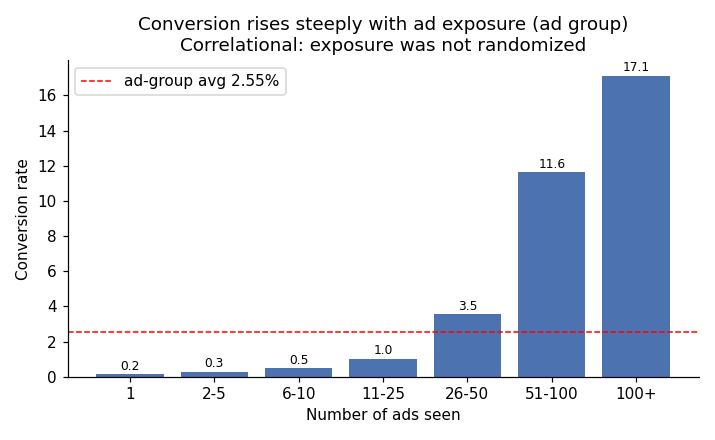

In [ ]:
ad = df[df.test_group == "ad"].copy()
bins = [0,1,5,10,25,50,100,np.inf]
labels = ["1","2-5","6-10","11-25","26-50","51-100","100+"]
ad["bucket"] = pd.cut(ad.total_ads, bins=bins, labels=labels, include_lowest=True)
bucket = ad.groupby("bucket", observed=True)["converted"].agg(rate="mean", users="count")
bucket["rate_%"] = (bucket["rate"]*100).round(3)
print("conversion by number of ads seen (ad group):")
print(bucket[["users","rate_%"]].to_string())

print("\naverage ads seen:")
print(ad.groupby("converted")["total_ads"].mean().round(1).to_string())

Conversion runs from **0.16%** for people who saw a single ad to **17%** for those who saw more than 100, and converters averaged **84** ads versus **23** for non-converters.

The catch: `total_ads` was not randomly assigned. People who were already interested tend to browse more, return more often, and therefore see more ads, so heavier exposure is partly a marker of an already-engaged user, not purely a cause of conversion. The clean randomized comparison stays the **ad vs. psa** result from section 4. The exposure pattern is real and useful as a signal, but it is correlational, and a frequency-capping decision would need its own randomized test to settle.

## 8. Timing: which day landed best

The ad group also records the day each user saw the most ads. That gives a rough read on which day of the week converted best, useful for scheduling spend.

              users  rate_%
most_ads_day               
Monday        83571   3.324
Tuesday       74572   3.044
Wednesday     77418   2.536
Thursday      79077   2.164
Friday        88805   2.246
Saturday      78802   2.131
Sunday        82332   2.462

best day: Monday (3.32%)
worst day: Saturday (2.13%)


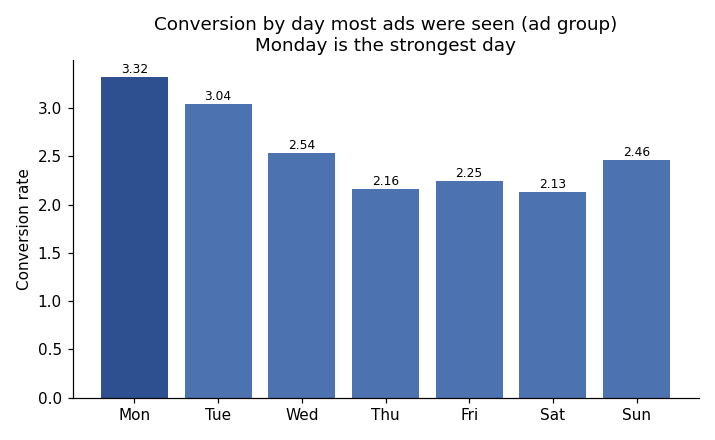

In [ ]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day = ad.groupby("most_ads_day")["converted"].agg(rate="mean", users="count").reindex(order)
day["rate_%"] = (day["rate"]*100).round(3)
print(day[["users","rate_%"]].to_string())
print(f"\nbest day: {day['rate_%'].idxmax()} ({day['rate_%'].max():.2f}%)")
print(f"worst day: {day['rate_%'].idxmin()} ({day['rate_%'].min():.2f}%)")

Monday converts best at **3.32%** and Thursday worst at **2.16%**, so the day a campaign leans on does matter, with early-week exposure outperforming the back half of the week by more than a percentage point.

## 9. Conclusion

- The campaign **worked**. The ad group converted at 2.55% versus 1.79% for the control, a 0.77 pp absolute and +43% relative lift, significant at p well below 0.001 by both a z-test and a chi-square test.
- The effect is **precise enough to act on**. The 95% interval on the lift is about [0.60, 0.94] pp, confirmed by a bootstrap where no resample crossed zero.
- The **exposure pattern is a signal, not a proven lever**. Conversion rises sharply with ads seen, but exposure was not randomized, so it cannot be read as proof that more impressions cause more conversions.
- **Timing helps.** Early-week exposure, Monday especially, converted best.

**What I would do with it.** Keep running the ad, since the lift is real and clearly beats the control. Before spending more on raw frequency, run a dedicated randomized test on impression count, because the exposure curve is confounded by user engagement. And weight delivery toward early in the week, where conversion is strongest.

**One caveat on power.** The control group is only 4% of users. It was large enough to detect this effect cleanly, but a smaller true lift could have been missed. A more balanced split would buy precision for future tests.